# COVID-19 Chest X-Ray Classifier

This notebook tours the project: the data split, training curves, evaluation and Grad-CAM explanations.
The heavy lifting lives in the `covid_classifier` folder, so every step here can be run from the command line:

```bash
python -m covid_classifier.data       # download dataset + write train/validation/test split
python -m covid_classifier.train      # fine-tune ResNet-18 and keep the best checkpoint
python -m covid_classifier.evaluate   # test-set metrics, confusion matrix, ROC curves
python -m covid_classifier.gradcam    # Grad-CAM figure
```

This notebook assumes those have been run, and loads the checkpoint and saved results rather than retraining.

In [ ]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

from covid_classifier import plotting as P
from covid_classifier.config import CHECKPOINT, CLASSES, CLASS_LABELS, RESULTS_DIR, SPLITS_CSV
from covid_classifier.data import ChestXRayDataset, denormalize, make_splits, split_counts
from covid_classifier.evaluate import compute_metrics, format_metrics, plot_confusion_matrix, plot_roc_curves, predict
from covid_classifier.gradcam import GradCAM, pick_examples, plot_gradcam
from covid_classifier.model import get_device, load_model
from covid_classifier.train import plot_history

## 1. Data

The [COVID-19 Radiography Database](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database) is split 8:1:1 per class (stratified, seed 42).
The split is stored in the kagglehub cache as a CSV containing paths so no images are copied.

- **train**: model fitting, with a class-balanced sampler to offset the approximately 8:1 Normal : Viral imbalance
- **val**: picks the best epoch (validation)
- **test**: only touched once for the final numbers below

In [2]:
if not SPLITS_CSV.exists():
    make_splits()

counts = split_counts()
print(f"{'':8}" + "".join(f'{CLASS_LABELS[c]:>18}' for c in CLASSES) + f'{'total':>9}')

for split, row in counts.items():
    print(f"{split:8}" + ''.join(f'{row[c]:>18,}' for c in CLASSES) + f'{sum(row.values()):>9,}')

                    Normal   Viral pneumonia          COVID-19    total
train                8,154             1,077             2,892   12,123
val                  1,019               134               362    1,515
test                 1,019               134               362    1,515


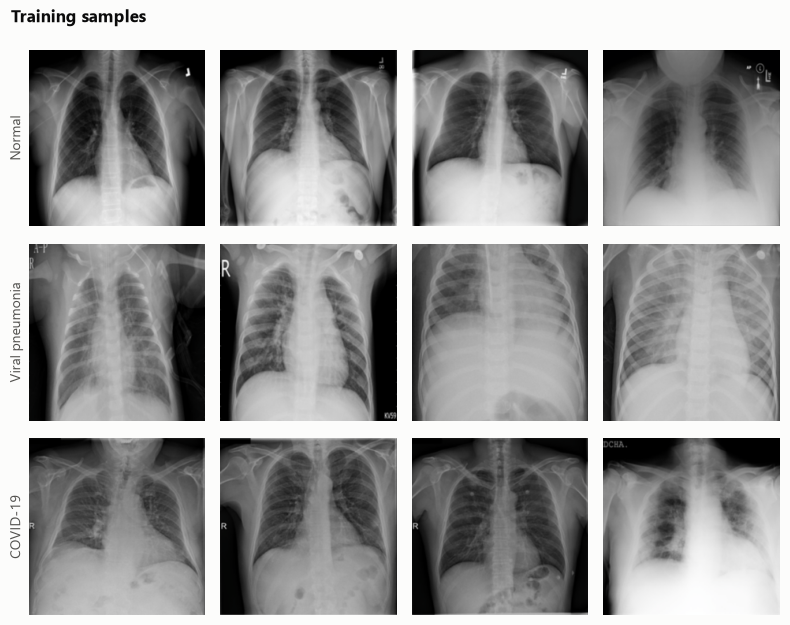

In [3]:
train_ds = ChestXRayDataset('train')
rng = np.random.default_rng(1)
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(8, 6.4))

for i, c in enumerate(CLASSES):
    idx = rng.choice(np.flatnonzero(np.array(train_ds.labels) == i), 4, replace=False)
    for ax, j in zip(axes[i], idx):
        ax.imshow(denormalize(train_ds[j][0]))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values(): s.set_visible(False)
    axes[i, 0].set_ylabel(CLASS_LABELS[c])

fig.suptitle('Training samples', x=0.02, ha='left', fontweight='bold')
fig.tight_layout()

## 2. Training

ImageNet-pretrained ResNet-18 with a new 3-way head finetuned with AdamW and a cosine learning-rate schedule.
Each epoch draws 3,000 class-balanced training images and the checkpoint with the best validation **balanced accuracy** is kept.

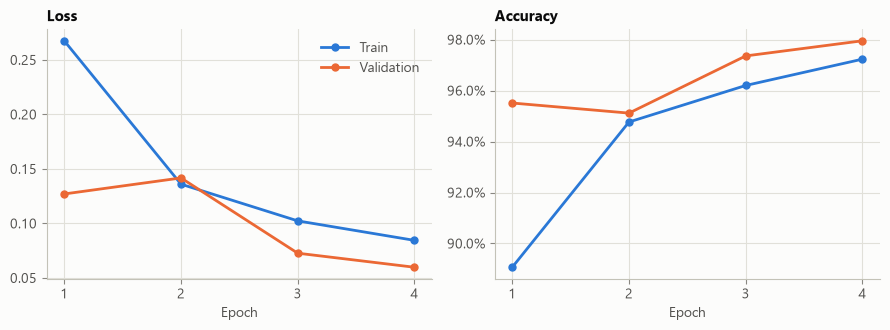

In [4]:
history = json.loads((RESULTS_DIR / 'history.json').read_text())
plot_history(history);

## 3. Test set evaluation

Each test image is scored once. Since the test set is imbalanced, balanced accuracy and per-class recall are more informative than simple accuracy.

In [5]:
device = get_device()
model = load_model(CHECKPOINT, device)
test_ds = ChestXRayDataset('test')
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64)
probs, labels = predict(model, test_loader, device)

metrics = compute_metrics(probs, labels)
print(format_metrics(metrics))

n=1515  accuracy=0.9815  balanced_accuracy=0.9741  macro_f1=0.9754  loss=0.0469
   class precision  recall      f1     auc  support
  normal    0.9853  0.9872  0.9863  0.9988     1019
   viral    0.9699  0.9627  0.9663  0.9997      134
   covid    0.9751  0.9724  0.9737  0.9991      362


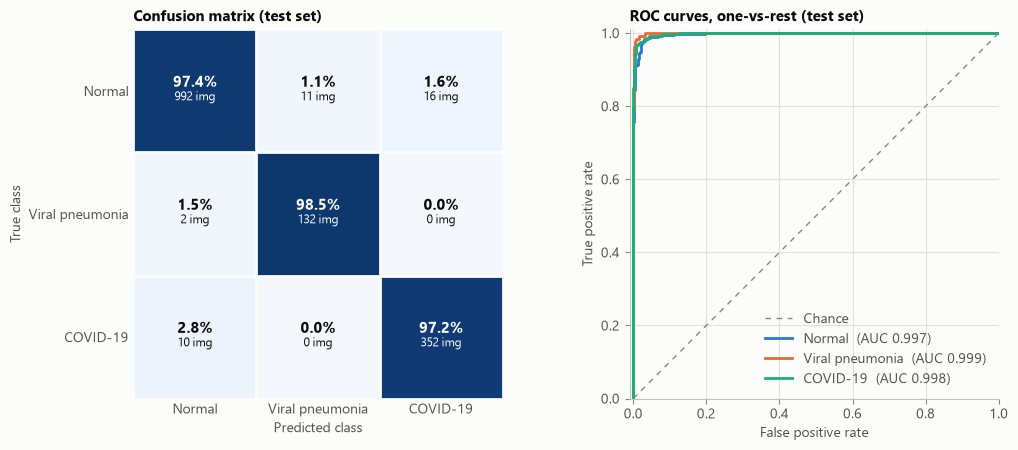

In [ ]:
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.6))
plot_confusion_matrix(metrics['confusion_matrix'], ax_cm)
plot_roc_curves(probs, labels, ax_roc)
fig.tight_layout()

## 4. Grad-CAM

[Grad-CAM](https://doi.org/10.1007/s11263-019-01228-7) weighs the last convolutional block's feature maps by the gradient of the predicted class score, giving a map of the regions that the model looked at to find its answer.
A trustworthy model should focus on the lung fields. Attention on text markers, borders or devices would hint at shortcut learning.

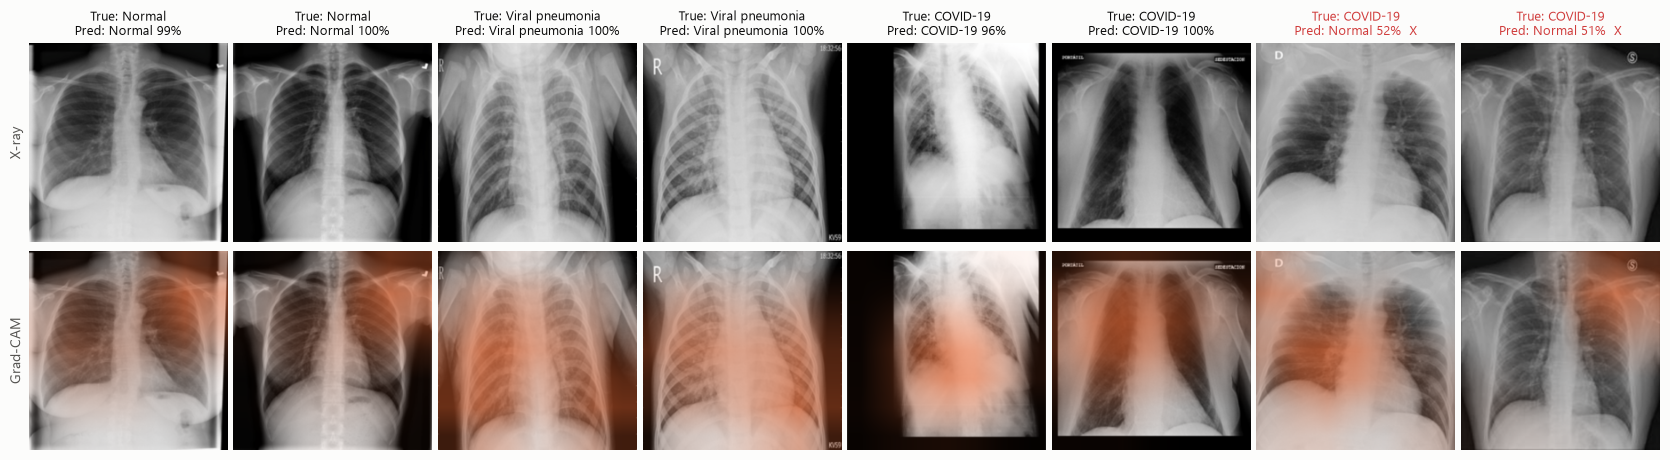

In [6]:
idx = pick_examples(probs, labels, n_per_class=2, n_errors=2)
images = torch.stack([test_ds[i][0] for i in idx]).to(device)

with GradCAM(model) as cam:
    heatmaps, cam_probs = cam(images)
    
plot_gradcam(images, heatmaps, cam_probs, labels[idx]);

## 5. Areas with limitations

The least confident mistakes are generally made on ambiguous images. The most confident mistakes are investigated for label noise or dataset artefacts below.

28 of 1515 test images misclassified


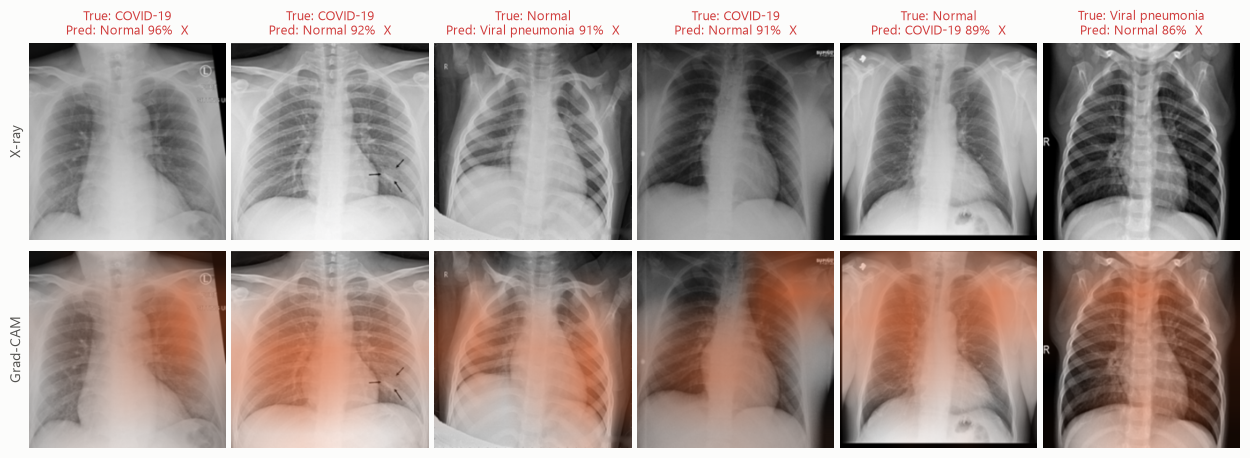

In [7]:
preds = probs.argmax(1)
wrong = np.flatnonzero(preds != labels)
worst = wrong[np.argsort(-probs[wrong, preds[wrong]])][:6] # most confident mistakes
print(f'{len(wrong)} of {len(labels)} test images misclassified')

images = torch.stack([test_ds[i][0] for i in worst]).to(device)
with GradCAM(model) as cam:
    heatmaps, cam_probs = cam(images)
plot_gradcam(images, heatmaps, cam_probs, labels[worst]);

---
**Educational project**, *not a medical device and not for diagnosis.*